In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

In [12]:
# Movement model
move_delta = {
    "U": (-1, 0),
    "D": ( 1, 0),
    "L": ( 0,-1),
    "R": ( 0, 1),
}

In [13]:
# loaders: maze.json
def load_maze(filename="data/maze.json"):
    """
    Reads the maze definition exported for Go:
    """
    with open(filename, "r") as f:
        data = json.load(f)

    maze = np.array(data["maze"])
    start_point = tuple(data["start"])  
    end_point   = tuple(data["end"])    

    return maze, start_point, end_point

In [14]:
# loaders: best_path.json
def load_best_path(filename="data/best_path.json"):
    """
    Reads the best path exported by Go:
    Returns the path as a list of moves like ["R","R","D",...]
    """
    with open(filename, "r") as f:
        data = json.load(f)

    path_moves = data["path"]
    return path_moves

In [15]:
# helpers for turning moves into coordinates for plotting
def convert_moves_to_positions(path_moves, start):
    """
    path_moves: e.g. ["R","R","D","D","L",...]
    start: (row, col)
    returns list of grid positions visited along the path
    """
    x, y = start
    positions = [(x, y)]

    for mv in path_moves:
        dx, dy = move_delta[mv]
        x += dx
        y += dy
        positions.append((x, y))

    return positions

In [16]:
# Visualization
def visualize(maze, start_point, end_point, path_moves=None, figsize=(20,7)):
    """
    Draw the maze with a visible white border on dark background.
    If path_moves is given, draw the discovered GA path in luminous green.
    """

    # Maze mask: 1=wall (black), 0=open (white)
    display_maze = np.where(maze == 1000, 1, 0)

    # black for 1, white for 0
    cmap = LinearSegmentedColormap.from_list(
        "custom_maze",
        [(0, 0, 0), (1, 1, 1)],
        N=2
    )

    fig, ax = plt.subplots(figsize=figsize)

    # Draw maze
    ax.imshow(display_maze, cmap=cmap, interpolation='nearest')

    # Draw path if present
    if path_moves is not None and len(path_moves) > 0:
        positions = convert_moves_to_positions(path_moves, start_point)

        # note: imshow uses matrix coords -> (row=y, col=x)
        ys = [row for (row, col) in positions]
        xs = [col for (row, col) in positions]

        # glow underlay
        ax.plot(
            xs, ys,
            linewidth=8,
            color=(0.0, 1.0, 0.0, 0.25),
            solid_capstyle='round',
            zorder=4
        )

        # Main bright path
        ax.plot(
            xs, ys,
            linewidth=4,
            color='lime',
            solid_capstyle='round',
            zorder=5
        )

        # Dots along path
        ax.scatter(
            xs, ys,
            s=30,
            c='lime',
            edgecolors='black',
            linewidths=0.5,
            zorder=6
        )

    # Start (blue)
    start_rect = patches.Rectangle(
        (start_point[1] - 0.5, start_point[0] - 0.5),
        1, 1,
        linewidth=1,
        edgecolor='blue',
        facecolor='blue',
        zorder=7
    )
    ax.add_patch(start_rect)

    # End (red)
    end_rect = patches.Rectangle(
        (end_point[1] - 0.5, end_point[0] - 0.5),
        1, 1,
        linewidth=1,
        edgecolor='red',
        facecolor='red',
        zorder=7
    )
    ax.add_patch(end_rect)

    # Border around full maze
    border_rect = patches.Rectangle(
        (-0.5, -0.5),
        maze.shape[1],
        maze.shape[0],
        linewidth=3,
        edgecolor='white',
        facecolor='none',
        zorder=8
    )
    ax.add_patch(border_rect)

    # ----- clean axes -----
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, maze.shape[1] - 0.5)
    ax.set_ylim(maze.shape[0] - 0.5, -0.5)

    # dark background outside maze
    ax.set_facecolor("#2b2e34")
    fig.patch.set_facecolor("#2b2e34")

    plt.show()

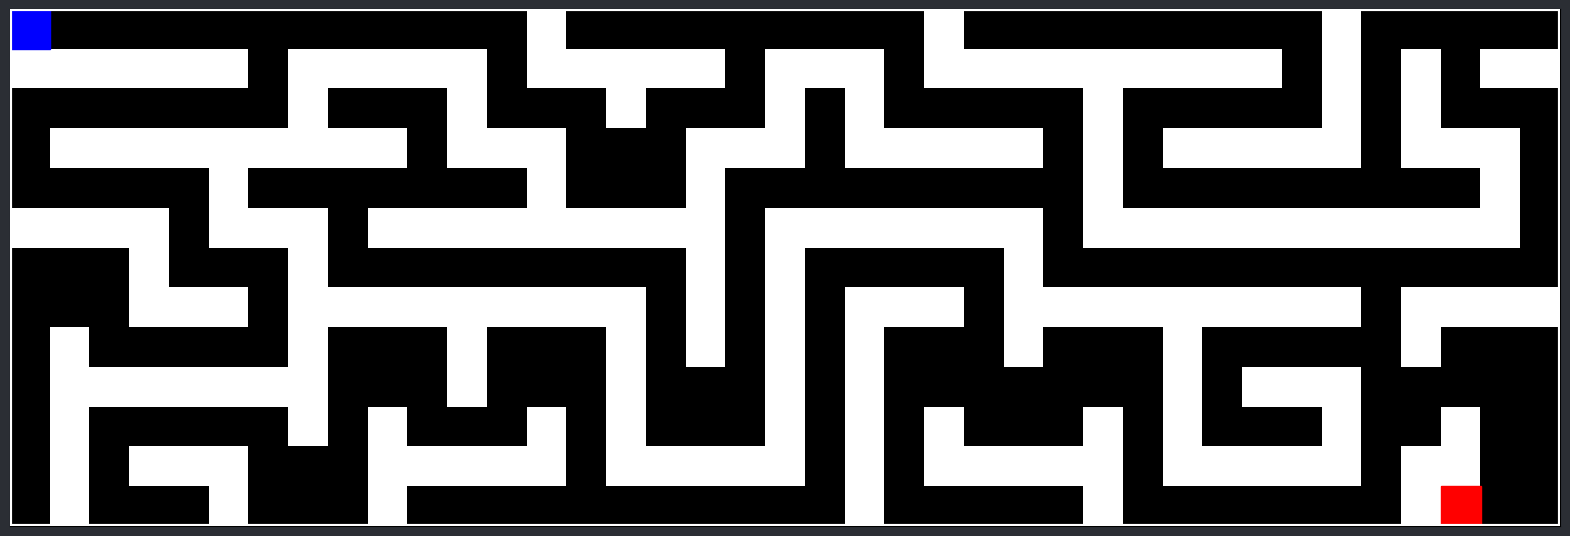

In [17]:
# Show maze without any solution path
maze, start_point, end_point = load_maze("data/maze.json")
visualize(maze, start_point, end_point, path_moves=None)

In [18]:
# load best_path.json that was generated by Go
best_path_moves = load_best_path("data/best_path.json")
print("Best GA path (moves):", best_path_moves)

Best GA path (moves): ['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'D', 'D', 'R', 'R', 'D', 'R', 'R', 'U', 'R', 'R', 'U', 'U', 'R', 'R', 'R', 'R', 'D', 'D', 'R', 'R', 'R', 'R', 'D', 'D', 'D', 'D', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'D', 'D', 'D', 'R', 'R', 'R', 'D', 'D', 'D', 'L']


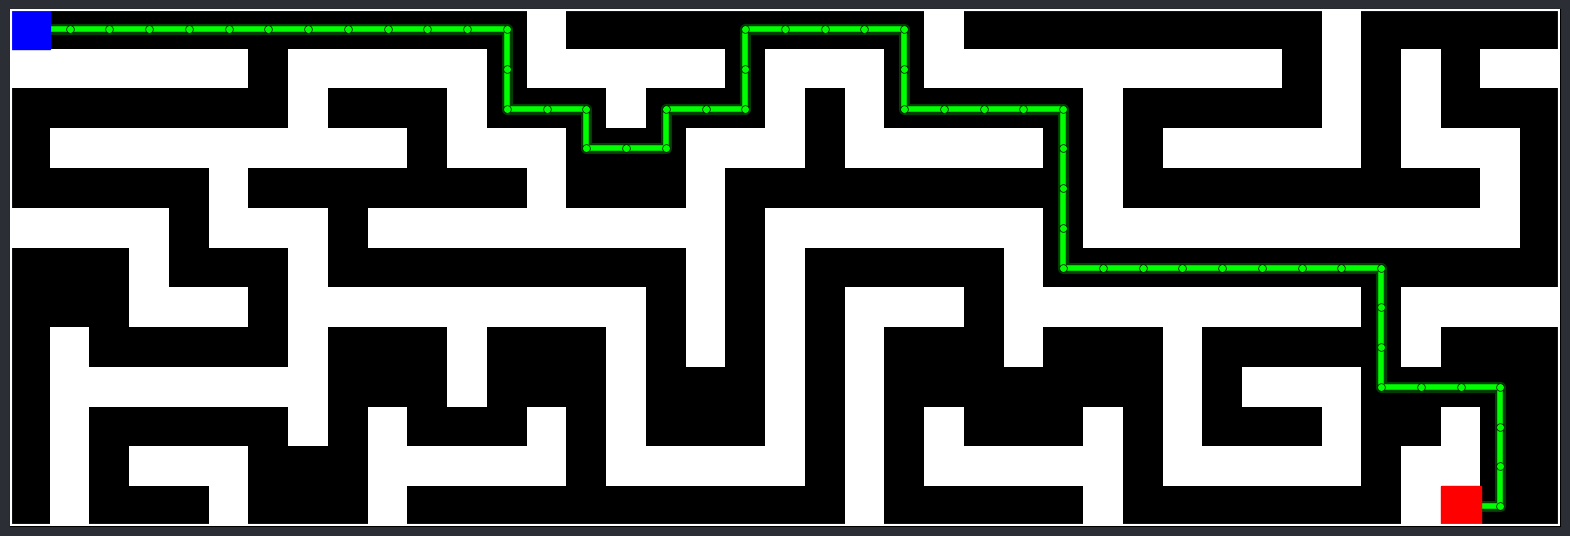

In [19]:
# Show maze and GA solution path
visualize(maze, start_point, end_point, path_moves=best_path_moves)